In [1]:

import numpy as np
import torch
import torchvision
import PIL
import matplotlib.pyplot as plt
import utils
import exp_models

In [2]:

# Reproducibility
SEED = 2019

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True   

In [3]:
BATCH_SIZE = 100
NUM_WORKERS = 8

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR100(root='/data/landelle/datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='/data/landelle/datasets', train=False, download=True, transform=transform)


Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(testset) // BATCH_SIZE
NUM_WORKERS = 8

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


In [5]:

def pixelgraft_data(X, y, pr, device):
    """
    Mixes data n ways with itself shuffled without overlaps, returns X_mixed and an array of every y shuffling
    Example:
        mixup_data(3, X, y, (.5, .5, 0)) will return X_mixed, y[permutation0], y[permutation1], y[permutation2]
        and X_mixed will veriy X_mixed = .5*X[permutation0] + .5*X[permutation1] + 0*X[permutation2]
    X: tensor of shape (batch_size, w, h, 3)
    y: tensor of shape (batch_size,)
    lam_: tensor of shape (n_ways, 1, 1, 1, 1)
    """
    assert X.shape[0] == y.shape[0]
    assert 0 <= pr <= 1
    perms = utils.no_overlap_perms_random(2, X.shape[0])
    #print(perms)
    X_permutations = torch.stack([X[perm] for perm in perms], 0)
    
    # compute the amount of pixels in image
    img_flat_size = X.shape[2] * X.shape[3]
    #print(img_flat_size)
    
    # create a mask that select 100pr% pixels of image 0 and 100(1-pr)% of image 1.
    graft_idx = (torch.rand(img_flat_size).to(device) < pr).int()
    
    #print(graft_idx)
    #print(1-graft_idx)
    
    #print(X_permutations.shape)
    
    lam_ = torch.stack((graft_idx, 1-graft_idx))
    lam_ = lam_.reshape((2, 1, 1, 32, 32)).float()
    #print(lam_)
    
    X_mixed = (X_permutations * lam_).sum(axis=0)
    ys = [y[perm] for perm in perms]
    
    #print(X_mixed)
    return X_mixed, ys, perms


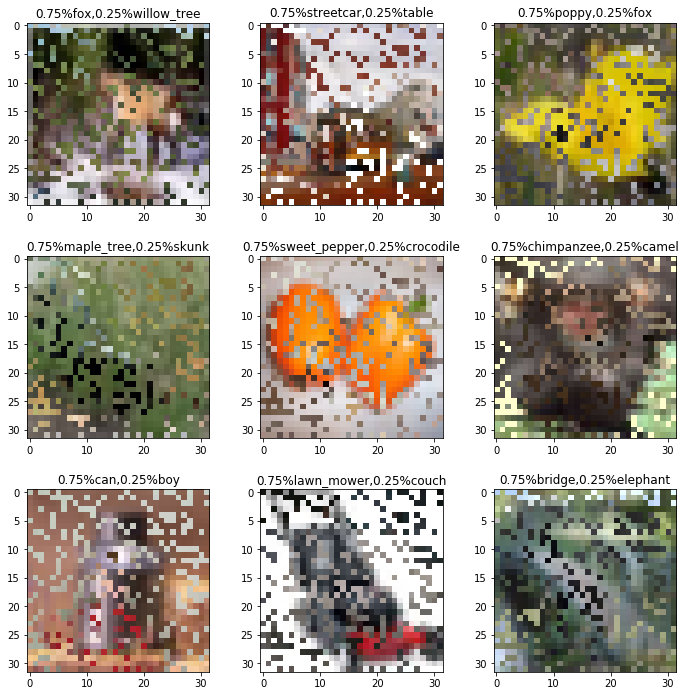

In [6]:
USE_CUDA = True
device = torch.device('cuda' if USE_CUDA else 'cpu')

pr = .75

for batch_id, (images, labels) in enumerate(trainloader):
    if batch_id == 0:
        X_graft, ys, perms = pixelgraft_data(images.to(device), labels.to(device), pr, device)
        break
    

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
plt.tight_layout(pad=2)
for j in range(3):
    for i in range(3):
        utils.show_np_arr(X_graft.cpu()[j*3+i], ax=axes[j, i])
        axes[j, i].set_title(str(pr)[:4] + "%" + trainset.classes[ys[0][j*3+i]] + "," +
                          str(1-pr)[:4] + "%" + trainset.classes[ys[1][j*3+i]], rotation=0)

In [7]:

USE_CUDA = True
N_EPOCHS = 100
N_BATCHES = None
LR = 0.001

model_getter = lambda: exp_models.resnet18(n=100)


def perform_experiment(prs):
    print("saving results in", RESULTS_FNAME)
    print_ = utils.get_print(True, fname=RESULTS_FNAME)
    test_accs = {}
    train_losses = {str(k):[] for k in prs}
    val_losses = {str(k):[] for k in prs}
    
    for pr in prs:
        print_("Trying pr=", pr) 

        device = torch.device('cuda' if USE_CUDA else 'cpu')
        model = model_getter().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = torch.nn.CrossEntropyLoss()
        
        pr_rs_tensor = torch.Tensor([pr, 1-pr]).reshape((2, 1, 1, 1, 1)).to(device)

        # Train mode
        model.train()
        for epoch in range(1, N_EPOCHS + 1):
            # Training on all batches
            print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
            for batch_id, (images, labels) in enumerate(trainloader):
                if N_BATCHES and batch_id > N_BATCHES:
                    break
                labels, images = labels.to(device), images.to(device)
                images_mx, ys, perms = pixelgraft_data(images, labels, pr, device)
                outputs = model(images_mx)
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, pr_rs_tensor)
                loss_value = loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_losses[str(pr)].append(loss_value)
                if batch_id % 50 == 0:
                    print_('train loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                    
            # Validating on one batch
            for images, labels in testloader:
                correct = 0
                total = 0
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                val_acc = 100 * correct / total
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, pr_rs_tensor)
                loss_value = loss.item()

                print_('val loss:{:.4f} Epoch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS))
                print_('val acc:{:.4f} Epoch[{}/{}]'.format(
                        val_acc, epoch, N_EPOCHS))
                val_losses[str(pr)].append(loss_value)
                break

        # Test mode
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            # Output test accuracy
            test_acc = 100 * correct / total
            print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
            test_accs[str(pr)] = test_acc


        del device, model, optimizer, criterion
    return test_accs, train_losses, images_mx, ys


In [ ]:

    
for i in range(2):
    PRS = [.875, .75, .625, .5]
    RESULTS_FNAME = "r_cf100_rn18_graft_"+str(i)    

    with open("results/"+RESULTS_FNAME, "w"):pass
    test_accs, train_losses, images_mx, ys = perform_experiment(PRS)

#print(RESULTS_FNAME, PRS)

saving results in r_cf100_rn18_graft_0
Trying pr= 0.875
Epoch[1/100]
train loss:4.7519 Epoch[1/100] Batch[0/500]
train loss:4.2882 Epoch[1/100] Batch[50/500]
train loss:4.2405 Epoch[1/100] Batch[100/500]
train loss:4.1639 Epoch[1/100] Batch[150/500]
train loss:4.0211 Epoch[1/100] Batch[200/500]
train loss:3.8063 Epoch[1/100] Batch[250/500]
train loss:3.8148 Epoch[1/100] Batch[300/500]
train loss:3.7656 Epoch[1/100] Batch[350/500]
train loss:3.6577 Epoch[1/100] Batch[400/500]
train loss:3.7026 Epoch[1/100] Batch[450/500]
val loss:5.7838 Epoch[1/100]
val acc:18.0000 Epoch[1/100]
Epoch[2/100]
train loss:3.5357 Epoch[2/100] Batch[0/500]
train loss:3.5414 Epoch[2/100] Batch[50/500]
train loss:3.3261 Epoch[2/100] Batch[100/500]
train loss:3.4727 Epoch[2/100] Batch[150/500]
train loss:3.3484 Epoch[2/100] Batch[200/500]
train loss:3.3774 Epoch[2/100] Batch[250/500]
train loss:3.1332 Epoch[2/100] Batch[300/500]
train loss:3.3763 Epoch[2/100] Batch[350/500]
train loss:3.3459 Epoch[2/100] Batch[4

train loss:1.0931 Epoch[16/100] Batch[150/500]
train loss:1.1505 Epoch[16/100] Batch[200/500]
train loss:1.1168 Epoch[16/100] Batch[250/500]
train loss:1.1641 Epoch[16/100] Batch[300/500]
train loss:1.0665 Epoch[16/100] Batch[350/500]
train loss:1.1376 Epoch[16/100] Batch[400/500]
train loss:1.1516 Epoch[16/100] Batch[450/500]
val loss:6.3304 Epoch[16/100]
val acc:52.0000 Epoch[16/100]
Epoch[17/100]
train loss:1.1236 Epoch[17/100] Batch[0/500]
train loss:1.0772 Epoch[17/100] Batch[50/500]
train loss:1.1152 Epoch[17/100] Batch[100/500]
train loss:1.0695 Epoch[17/100] Batch[150/500]
train loss:1.1010 Epoch[17/100] Batch[200/500]
train loss:1.1022 Epoch[17/100] Batch[250/500]
train loss:1.1389 Epoch[17/100] Batch[300/500]
train loss:1.1016 Epoch[17/100] Batch[350/500]
train loss:1.1134 Epoch[17/100] Batch[400/500]
train loss:1.0968 Epoch[17/100] Batch[450/500]
val loss:6.5391 Epoch[17/100]
val acc:56.0000 Epoch[17/100]
Epoch[18/100]
train loss:1.0817 Epoch[18/100] Batch[0/500]
train loss:

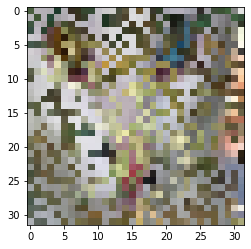

In [9]:


utils.show_np_arr(images_mx.cpu()[0])